In [1]:
import glob
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv("policy_runs/sim_events_55.csv")
df.head()

,timestamp,event_type,task_id,gpu_id,npts
0,2000,START,24,4,11916176
1,2000,START,95,4,7968444
2,2000,START,154,8,11683882
3,2000,START,112,8,8112870
4,2000,START,143,12,9207969


In [3]:
task_stats = df.groupby('task_id').agg(
    npts = ('npts','max'),
    start_time = ('timestamp','min'),
    finish_time = ('timestamp',lambda x: x[df.loc[x.index,'event_type']=='FINISH'].max()),
    interruptions=('event_type', lambda x: (x == 'INTERRUPT').sum())
).dropna()
task_stats['duration'] = (task_stats['finish_time'] - task_stats['start_time']) / 1000.0

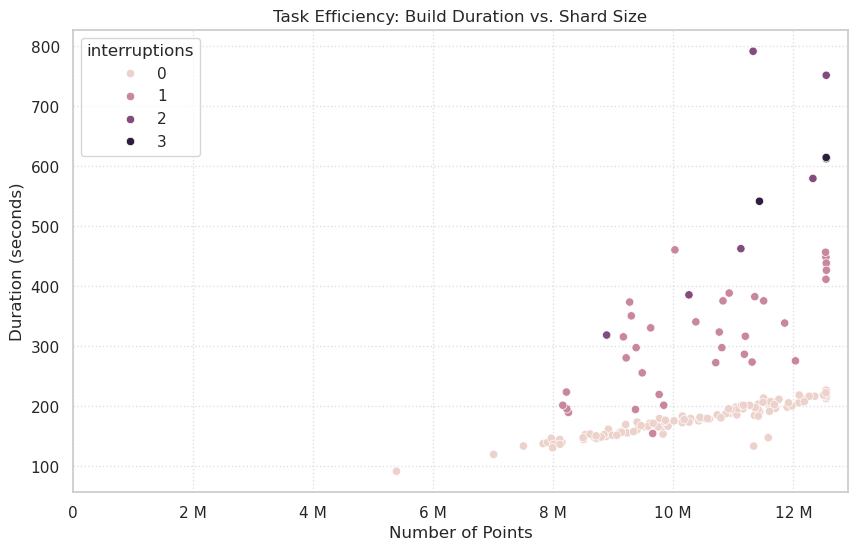

In [4]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=task_stats,x='npts',y='duration',hue='interruptions')
plt.gca().xaxis.set_major_formatter(ticker.EngFormatter())
plt.xlim(left=0)
plt.title('Task Efficiency: Build Duration vs. Shard Size')
plt.xlabel('Number of Points')
plt.ylabel('Duration (seconds)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [59]:
df2 = pd.read_csv("random_runs/sim_events_0.csv")
df2.head()

,timestamp,event_type,task_id,gpu_id,npts
0,2000,START,106,4,9138707
1,2000,START,144,4,10794100
2,2000,START,109,8,11329692
3,2000,START,84,8,8715480
4,2000,START,130,12,10445152


In [60]:
task_stats2 = df2.groupby('task_id').agg(
    npts = ('npts','max'),
    start_time = ('timestamp','min'),
    finish_time = ('timestamp',lambda x: x[df2.loc[x.index,'event_type']=='FINISH'].max()),
    interruptions=('event_type', lambda x: (x == 'INTERRUPT').sum())
).dropna()
task_stats2['duration'] = (task_stats2['finish_time'] - task_stats2['start_time']) / 1000.0

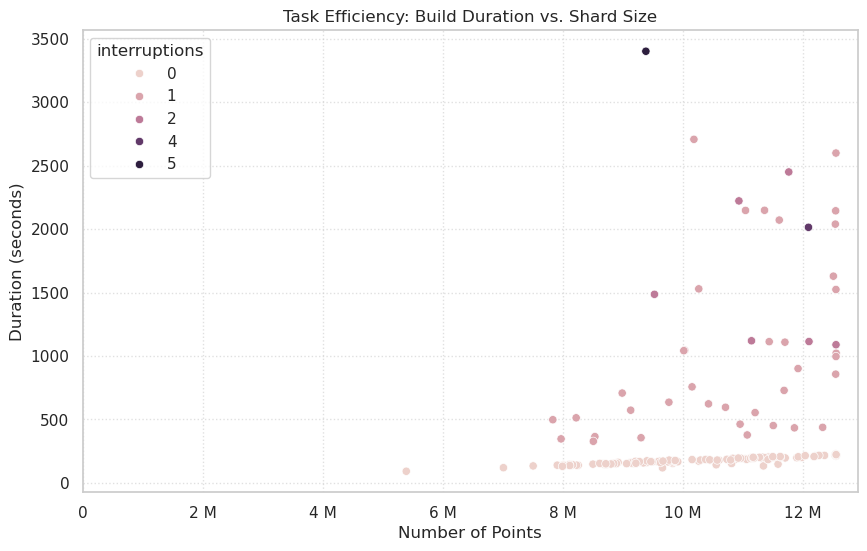

In [61]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=task_stats2,x='npts',y='duration',hue='interruptions')
plt.gca().xaxis.set_major_formatter(ticker.EngFormatter())
plt.xlim(left=0)
plt.title('Task Efficiency: Build Duration vs. Shard Size')
plt.xlabel('Number of Points')
plt.ylabel('Duration (seconds)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [2]:
starts = df[df['event_type'] == 'START'][['timestamp']].copy()
starts['change'] = 1
ends = df[df['event_type'].isin(['FINISH', 'INTERRUPT'])][['timestamp']].copy()
ends['change'] = -1
concurrency = pd.concat([starts, ends]).sort_values('timestamp')
concurrency['active_tasks'] = concurrency['change'].cumsum()

NameError: name 'df' is not defined

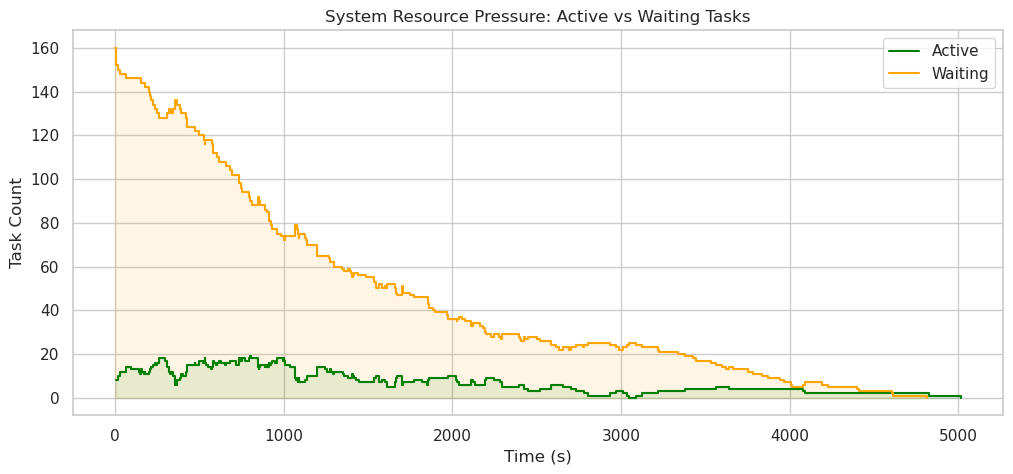

In [48]:
# Robust System Resource Pressure (Active vs Waiting)
def get_timeline_v2(df_in, start_types, end_types, init_count=0):
    starts = df_in[df_in['event_type'].isin(start_types)][['timestamp']].copy()
    starts['change'] = 1
    ends = df_in[df_in['event_type'].isin(end_types)][['timestamp']].copy()
    ends['change'] = -1
    tl = pd.concat([starts, ends]).sort_values('timestamp')
    tl = tl.groupby('timestamp')['change'].sum().reset_index()
    if init_count > 0:
        tl = pd.concat([pd.DataFrame([{'timestamp': 0, 'change': init_count}]), tl])
    tl['count'] = tl['change'].cumsum()
    return tl

active_tasks = get_timeline_v2(df, ['START'], ['FINISH', 'INTERRUPT'])
waiting_tasks = get_timeline_v2(df, ['INTERRUPT'], ['START'])
# Assume all tasks are waiting at t=0 until their first START
initial_total = len(df['task_id'].unique())
waiting_tasks = pd.concat([pd.DataFrame([{'timestamp': 0, 'change': initial_total}]), waiting_tasks]).sort_values('timestamp')
waiting_tasks['count'] = waiting_tasks['change'].cumsum().clip(lower=0)

plt.figure(figsize=(12, 5))
plt.step(active_tasks['timestamp']/1000, active_tasks['count'], label='Active', color='green', where='post')
plt.step(waiting_tasks['timestamp']/1000, waiting_tasks['count'], label='Waiting', color='orange', where='post')
plt.fill_between(active_tasks['timestamp']/1000, active_tasks['count'], alpha=0.1, color='green', step='post')
plt.fill_between(waiting_tasks['timestamp']/1000, waiting_tasks['count'], alpha=0.1, color='orange', step='post')
plt.title('System Resource Pressure: Active vs Waiting Tasks')
plt.xlabel('Time (s)'); plt.ylabel('Task Count'); plt.legend(); plt.show()

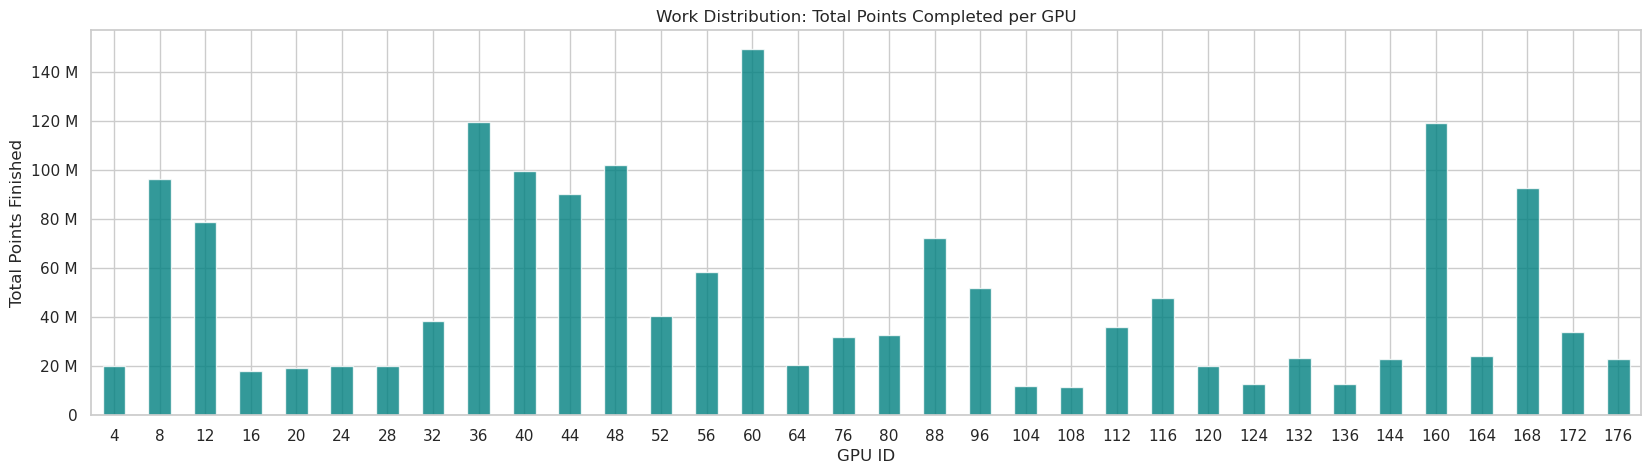

In [49]:
gpu_work = df[df['event_type'] == 'FINISH'].groupby('gpu_id')['npts'].sum().sort_index()
plt.figure(figsize=(20,5))
gpu_work.plot(kind='bar',color='teal',alpha=0.8)
plt.gca().yaxis.set_major_formatter(ticker.EngFormatter())
plt.title('Work Distribution: Total Points Completed per GPU')
plt.xlabel('GPU ID')
plt.ylabel('Total Points Finished')
plt.xticks(rotation=0)
plt.show()

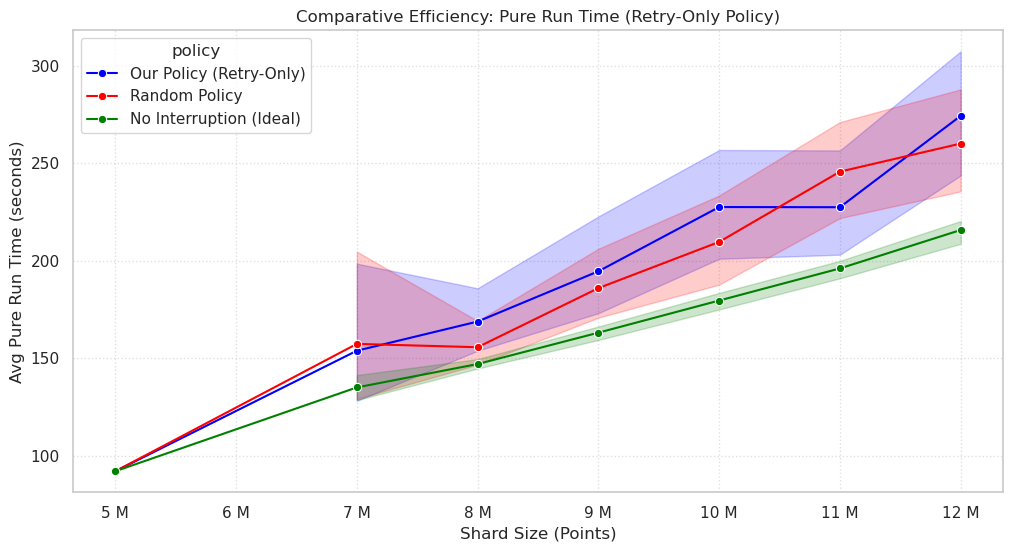

In [35]:
def get_true_pure_run_metrics(filename, label, delay_ms=0):
    df = pd.read_csv(filename)
    finished = df[df['event_type'] == 'FINISH']['task_id'].unique()
    df = df[df['task_id'].isin(finished)].sort_values(['task_id', 'timestamp'])
    df['timestamp'] = (df['timestamp'] - delay_ms).clip(lower=0)
    df['diff'] = df.groupby('task_id')['timestamp'].diff()
    df['prev_type'] = df.groupby('task_id')['event_type'].shift(1)
    run_mask = (df['prev_type'] == 'START') & df['event_type'].isin(['FINISH', 'INTERRUPT'])
    stats = df[run_mask].groupby('task_id').agg({'diff': 'sum', 'npts': 'max'}).reset_index()
    stats['pure_run_s'] = stats['diff'] / 1000.0
    stats['npts_bin'] = (stats['npts'] // 1_000_000) * 1_000_000
    return stats[['npts_bin', 'pure_run_s']].assign(policy=label)

df_all = pd.concat([
    get_true_pure_run_metrics("sim_events_policy.csv", "Our Policy (Retry-Only)", delay_ms=2000),
    get_true_pure_run_metrics("sim_events_random.csv", "Random Policy", delay_ms=2000),
    get_true_pure_run_metrics("sim_events_nopreempt.csv", "No Interruption (Ideal)", delay_ms=0)
])

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_all, x='npts_bin', y='pure_run_s', hue='policy', 
             marker='o', palette={'Our Policy (Retry-Only)': 'blue', 'Random Policy': 'red', 'No Interruption (Ideal)': 'green'})

plt.gca().xaxis.set_major_formatter(ticker.EngFormatter())
plt.title("Comparative Efficiency: Pure Run Time (Retry-Only Policy)")
plt.xlabel("Shard Size (Points)"); plt.ylabel("Avg Pure Run Time (seconds)")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [3]:
def get_stats(filename):
    df  = pd.read_csv(filename)
    df_ret = df.groupby('task_id').agg(
                npts=('npts', 'max'),
                start_time=('timestamp', 'min'),
                finish_time=('timestamp', lambda x: x[df.loc[x.index, 'event_type'] == 'FINISH'].max()),
                interruptions=('event_type', lambda x: (x == 'INTERRUPT').sum())
            ).dropna()
    df_ret['duration_s'] = (df_ret['finish_time'] - df_ret['start_time']) / 1000.0
    return df_ret

In [4]:
def get_aggregated_policy_stats(pattern, limit):
    files = sorted(glob.glob(pattern))
    files = files[:limit]
    all_runs = []
    print(f"Aggregating efficiency for {len(files)} policy runs...")
    
    for f in files:
        try:
            df_local = get_stats(f)
            all_runs.append(df_local[['npts', 'duration_s', 'interruptions']])
        except Exception as e:
            continue    
    if not all_runs: return pd.DataFrame()
    return pd.concat(all_runs)

In [16]:
def get_comparative_plots(df_policy_all,df_random_all,n_runs):
    df_ideal_stats = get_stats("sim_events_nopreempt.csv")
    plt.figure(figsize=(14, 8))
    #df_ideal_stats['pts_bin'] = (df_ideal_stats['npts'] // 1_000_000) * 1_000_000
    sns.lineplot(data=df_ideal_stats, x='npts', y='duration_s', label='Ideal Policy(0 pre-emptions)', color='green', lw=3, errorbar=('ci', 95), alpha=0.9, zorder=10)
    #df_policy_all['pts_bin'] = (df_policy_all['npts'] // 1_000_000) * 1_000_000
    sns.lineplot(data=df_policy_all, x='npts', y='duration_s', label=f'Our Hybrid Policy (Mean of {n_runs} runs)', color='blue', lw=3, errorbar=('ci', 95), alpha=0.9, zorder=10)
    #df_random_all['pts_bin'] = (df_random_all['npts'] // 1_000_000) * 1_000_000
    sns.lineplot(data=df_random_all, x='npts', y='duration_s', label=f'Random Policy (Mean of {n_runs} runs)', color='red', lw=3, errorbar=('ci', 95), alpha=0.9, zorder=10)
    plt.gca().xaxis.set_major_formatter(ticker.EngFormatter())
    plt.title(f"Aggregated Policy Efficiency: Build Duration vs Shard Size ({n_runs} Runs)")
    plt.xlabel("Shard Size (Points)")
    plt.ylabel("Residence Duration in System (seconds)")
    plt.legend(loc='upper left', shadow=True)
    return plt.show()
    

In [17]:
print("Processing 100 Policy Simulation logs...")
df_policy_all = get_aggregated_policy_stats("policy_runs/sim_events_*.csv",100)
df_random_all = get_aggregated_policy_stats("random_runs/sim_events_*.csv",100)

Processing 100 Policy Simulation logs...
Aggregating efficiency for 100 policy runs...
Aggregating efficiency for 100 policy runs...


In [18]:
df_policy_all.head()

,npts,duration_s,interruptions
task_id,,,
0,8727197,146.0,0
1,12550781,239.0,0
2,12542930,223.0,0
3,12547303,224.0,0
4,7503288,134.0,0


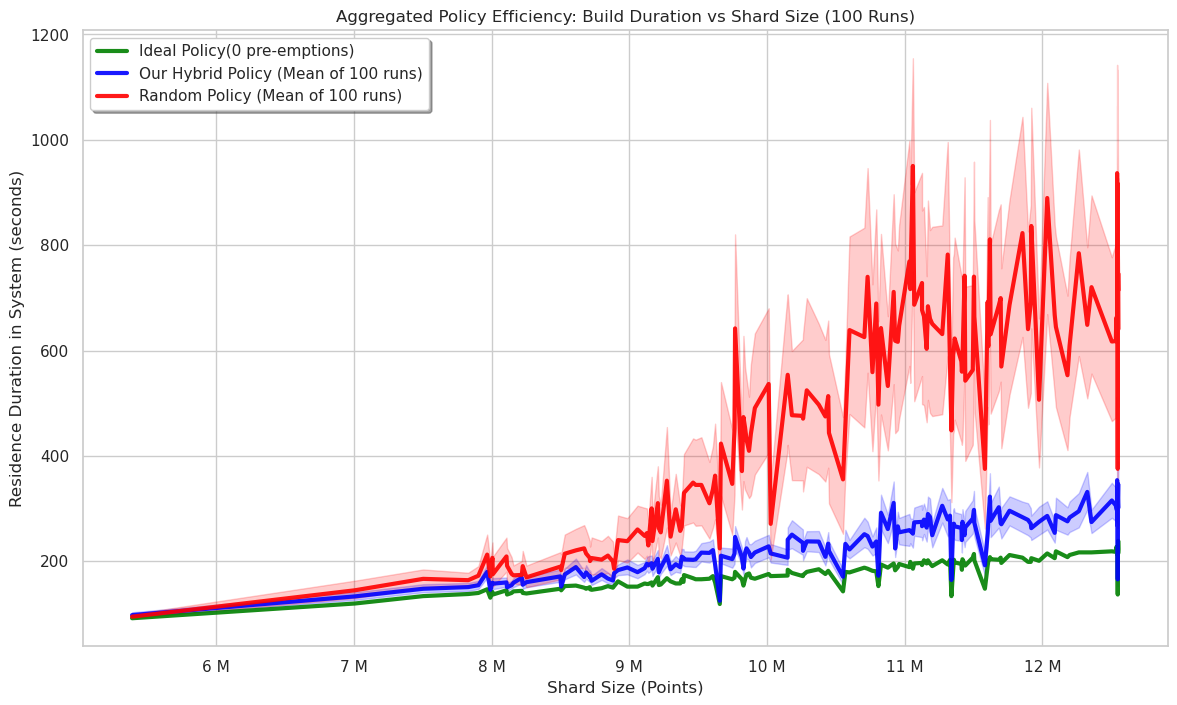

In [19]:
get_comparative_plots(df_policy_all,df_random_all,100)

In [20]:
print("Processing 200 Policy Simulation logs...")
df_policy_all = get_aggregated_policy_stats("policy_runs/sim_events_*.csv",200)
df_random_all = get_aggregated_policy_stats("random_runs/sim_events_*.csv",200)

Processing 200 Policy Simulation logs...
Aggregating efficiency for 200 policy runs...
Aggregating efficiency for 200 policy runs...


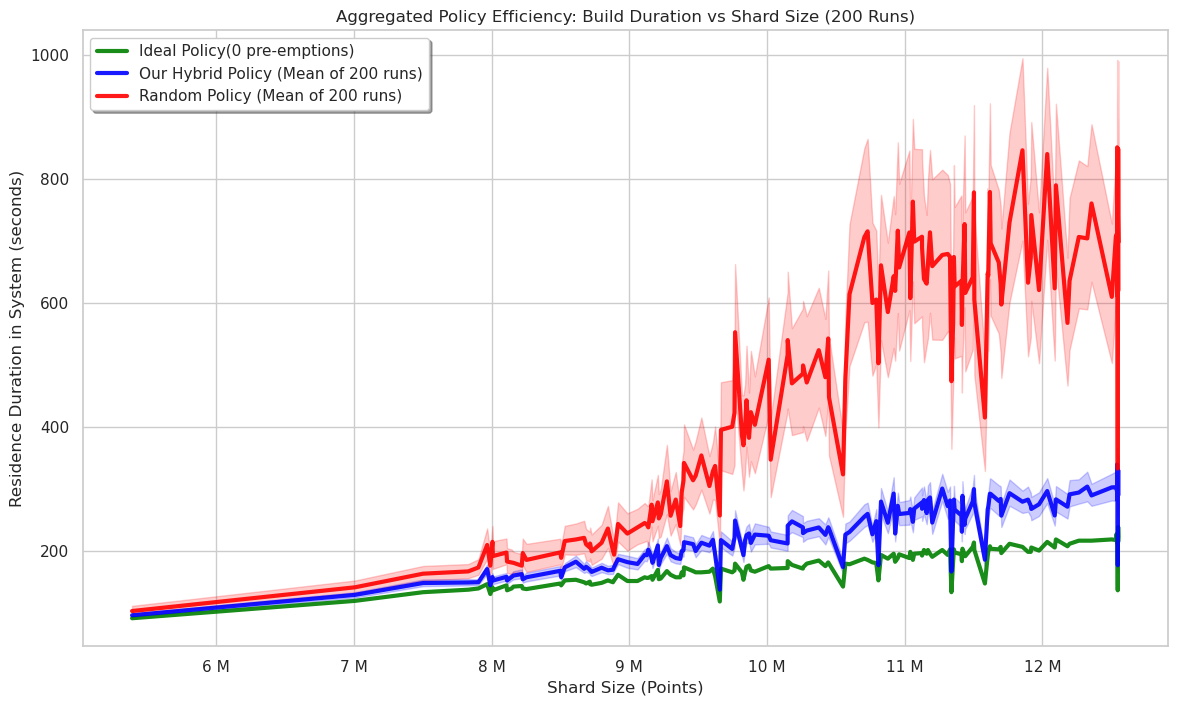

In [21]:
get_comparative_plots(df_policy_all,df_random_all,200)

In [22]:
print("Processing 300 Policy Simulation logs...")
df_policy_all = get_aggregated_policy_stats("policy_runs/sim_events_*.csv",300)
df_random_all = get_aggregated_policy_stats("random_runs/sim_events_*.csv",300)

Processing 300 Policy Simulation logs...
Aggregating efficiency for 300 policy runs...
Aggregating efficiency for 300 policy runs...


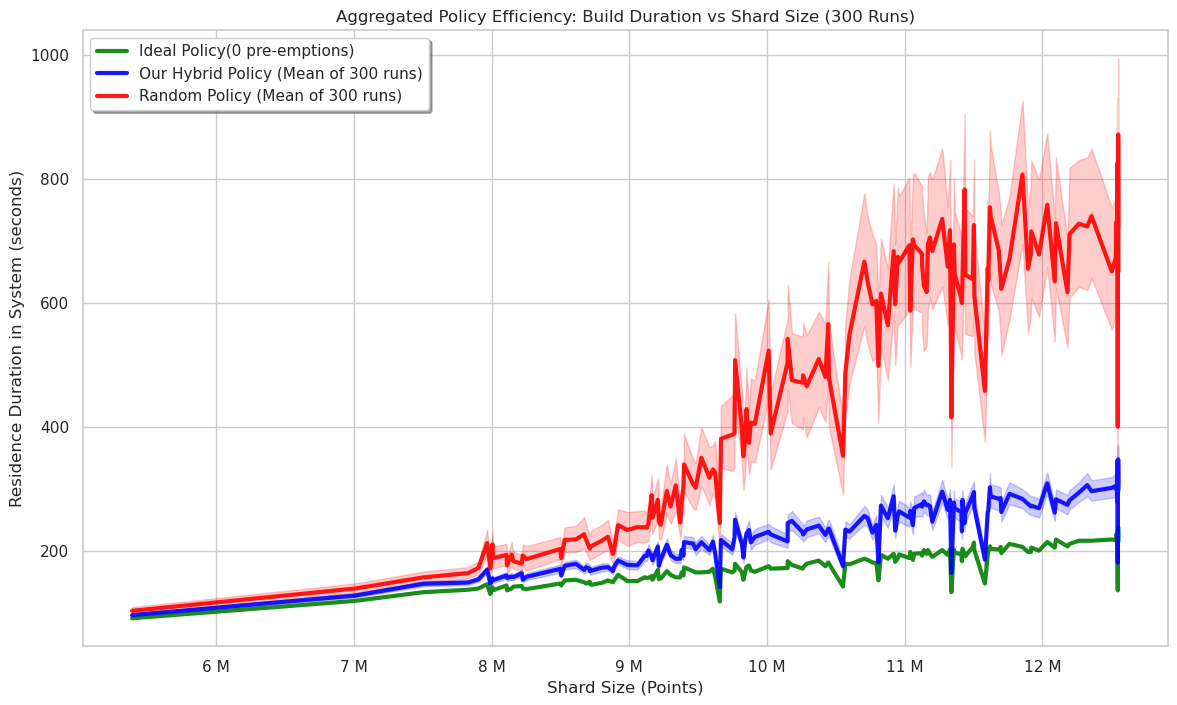

In [23]:
get_comparative_plots(df_policy_all,df_random_all,300)

In [24]:
print("Processing 300 Policy Simulation logs...")
df_policy_all = get_aggregated_policy_stats("policy_runs/sim_events_*.csv",500)
df_random_all = get_aggregated_policy_stats("random_runs/sim_events_*.csv",500)

Processing 300 Policy Simulation logs...
Aggregating efficiency for 500 policy runs...
Aggregating efficiency for 500 policy runs...


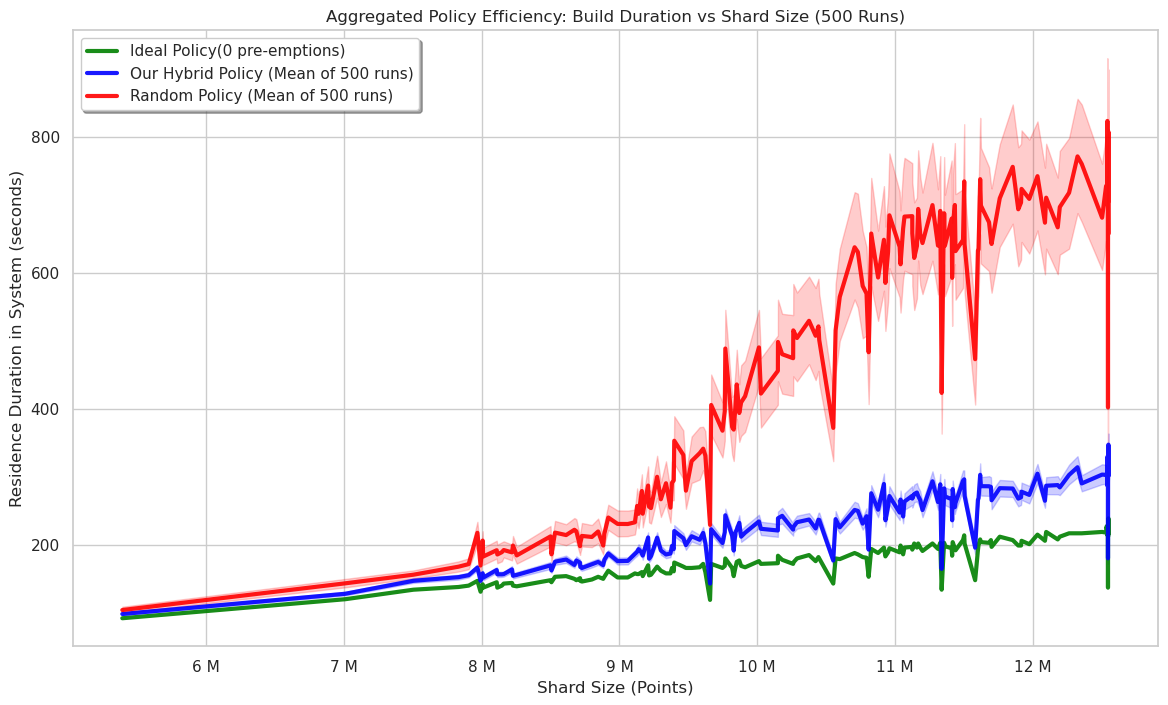

In [25]:
get_comparative_plots(df_policy_all,df_random_all,500)

In [80]:
batch_sizes = [100,200,300,400,500]
convergence_data = []

for batch in batch_sizes:
    df_batch = get_aggregated_policy_stats("policy_runs/sim_events_*.csv", batch)
    df_batch['batch_size'] = batch
    convergence_data.append(df_batch)

df_all_batches = pd.concat(convergence_data)

Aggregating efficiency for 100 policy runs...
Aggregating efficiency for 200 policy runs...
Aggregating efficiency for 300 policy runs...
Aggregating efficiency for 400 policy runs...
Aggregating efficiency for 500 policy runs...


In [84]:
df_all_batches['interruptions'].describe()

count    240000.000000
mean          0.347058
std           0.699490
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max           8.000000
Name: interruptions, dtype: float64

In [92]:
df_all_batches['npts'].describe()

count    2.400000e+05
mean     1.044576e+07
std      1.498451e+06
min      5.389737e+06
25%      9.262390e+06
50%      1.065366e+07
75%      1.161061e+07
max      1.255265e+07
Name: npts, dtype: float64

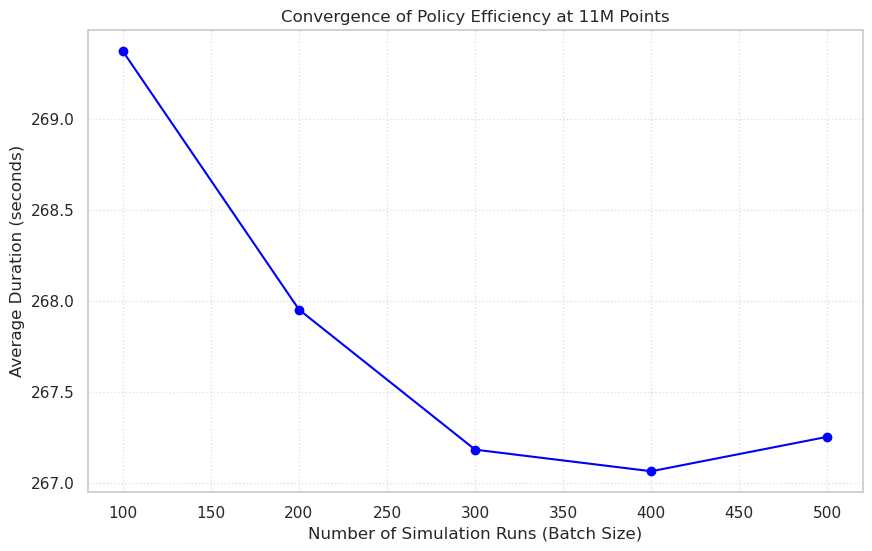

In [101]:
target_bins = 11_000_000
df_11m = df_all_batches[(df_all_batches['npts'] >=11_000_000) & (df_all_batches['npts']<12_000_000)]
mean_per_batch = df_11m.groupby('batch_size')['duration_s'].mean().reset_index()
plt.figure(figsize=(10,6))
plt.plot(mean_per_batch['batch_size'], mean_per_batch['duration_s'], marker='o', color='blue')
plt.title("Convergence of Policy Efficiency at 11M Points")
plt.xlabel("Number of Simulation Runs (Batch Size)")
plt.ylabel("Average Duration (seconds)")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [109]:
#Studying GPU trace patterns
gpu_df = pd.read_csv("p3-trace.csv")
gpu_df['sim_time_s'] = (gpu_df['timestamp'] * 0.1) / 1000.0
gpu_df['change'] = gpu_df['event_type'].map({'add': 1, 'remove': -1})
capacity = gpu_df.sort_values('sim_time_s').groupby('sim_time_s')['change'].sum().cumsum().reset_index(name='gpu_count')
gpu_df['sim_time_s'].describe()

count     344.000000
mean     1638.087209
std      1098.560672
min         0.000000
25%       538.500000
50%      1665.000000
75%      2526.000000
max      4092.000000
Name: sim_time_s, dtype: float64

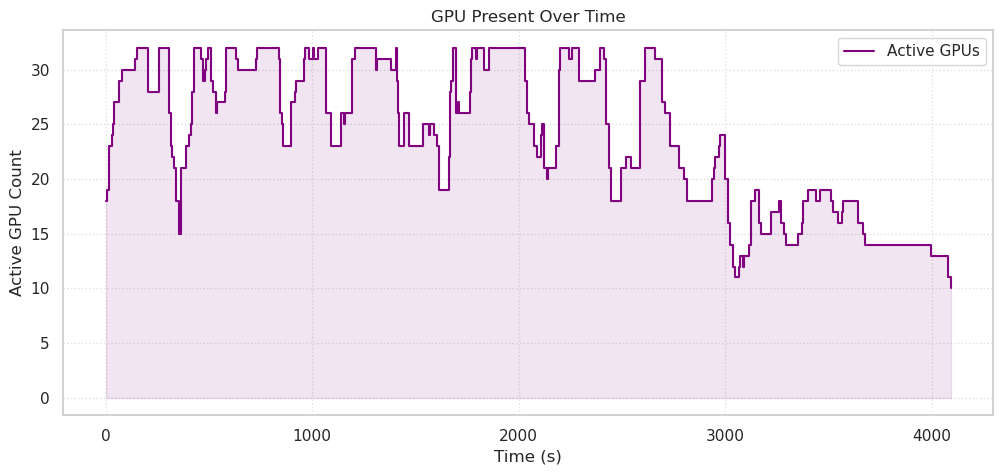

In [111]:
#Show GPU trends
plt.figure(figsize=(12, 5))
plt.step(capacity['sim_time_s'], capacity['gpu_count'], label='Active GPUs', color='purple', where='post')
plt.fill_between(capacity['sim_time_s'], capacity['gpu_count'], alpha=0.1, color='purple', step='post')
plt.title('GPU Present Over Time')
plt.xlabel('Time (s)'); plt.ylabel('Active GPU Count'); plt.legend(); plt.grid(True, linestyle=':', alpha=0.6); plt.show()
plt.show()
